# Plotter Notebook

This notebook loads evaluation outputs saved under `quantized_models/analysis/` and creates
visualizations that compare quantized models vs the baseline.

It is environment-agnostic and can be run in any Conda environment that has plotting
libraries installed.

In [ ]:
# Install plotting dependencies (run once)

import sys
import subprocess

REQUIRED = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
]

for pkg in REQUIRED:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("Dependencies verified.")

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

ANALYSIS_DIR = Path("./quantized_models/analysis")

# Load any evaluation CSVs found in the analysis directory
csv_files = sorted(ANALYSIS_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No evaluation CSVs found under {ANALYSIS_DIR}")

print("Found evaluation CSV files:")
for f in csv_files:
    print(f"  - {f}")

# Concatenate all results into a single DataFrame
dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    dfs.append(df)

results_df = pd.concat(dfs, ignore_index=True)

# Ensure required columns exist
required_cols = ["model_name", "perplexity", "weight_memory_gb", "bandwidth_gb_per_token", "bits"]
for col in required_cols:
    if col not in results_df.columns:
        raise ValueError(f"Expected column '{col}' in evaluation results")

results_df = results_df.dropna(subset=["perplexity"])

print(f"Loaded {len(results_df)} evaluation rows")

Found evaluation CSV files:
  - quantized_models/analysis/evaluation_awq_rtn_results.csv
  - quantized_models/analysis/evaluation_gptq_results.csv
  - quantized_models/analysis/evaluation_results.csv
Loaded 8 evaluation rows


Saved plot to quantized_models/analysis/tradeoff_analysis.png


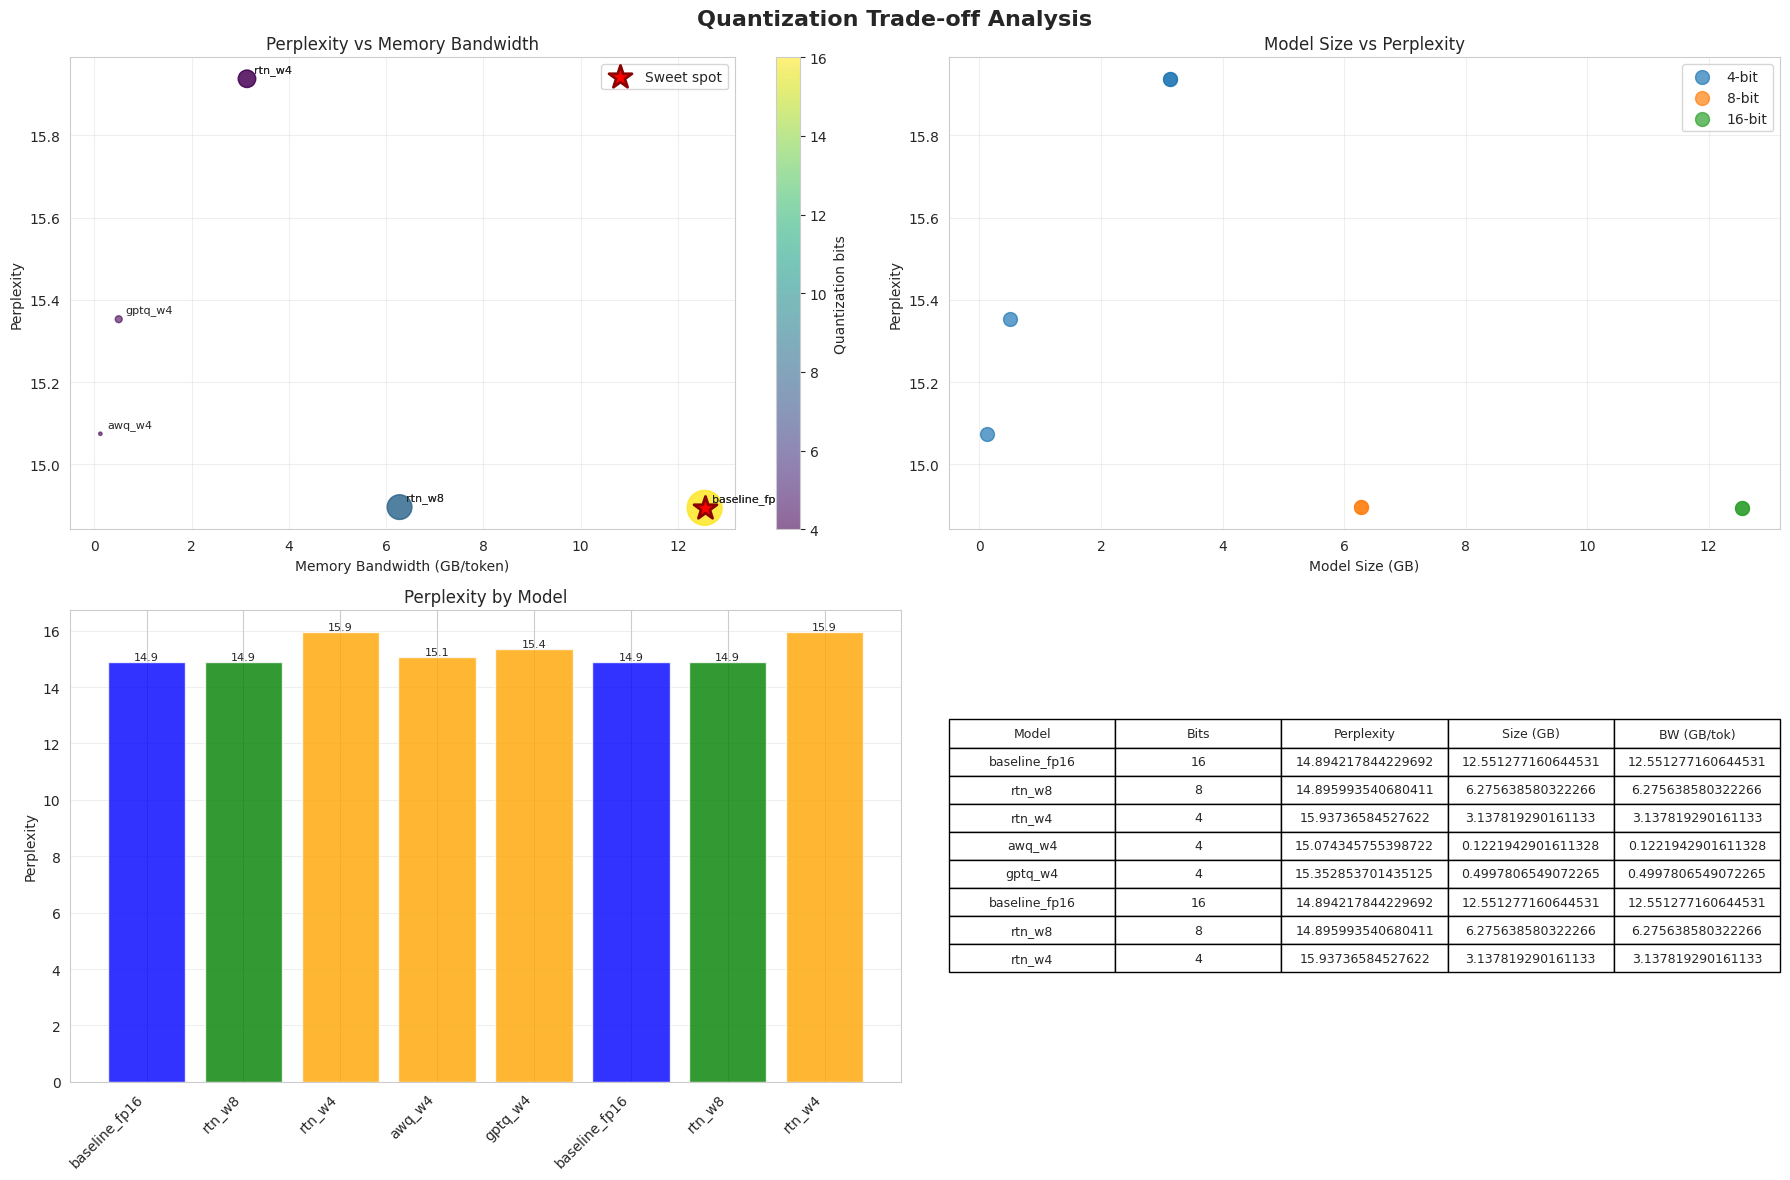


RECOMMENDATIONS
Sweet spot model: baseline_fp16 (16 bits)
  Perplexity: 14.89
  Size: 12.55 GB
  Bandwidth: 12.551 GB/token

Mobile (<2GB) recommendation: awq_w4 (4 bits)
  Perplexity: 15.07
  Size: 0.12 GB

Best accuracy: baseline_fp16 (16 bits)
  Perplexity: 14.89
  Size: 12.55 GB


In [2]:
# Plotting helpers

def plot_tradeoff_analysis(df: pd.DataFrame, output_path: Path = None):
    """Create trade-off visualizations from evaluation results."""

    df = df.copy()

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle("Quantization Trade-off Analysis", fontsize=16, fontweight="bold")

    # 1) Perplexity vs Bandwidth
    ax1 = axes[0, 0]
    scatter = ax1.scatter(
        df["bandwidth_gb_per_token"],
        df["perplexity"],
        s=df["weight_memory_gb"] * 50,
        alpha=0.6,
        c=df["bits"],
        cmap="viridis",
    )

    for _, row in df.iterrows():
        ax1.annotate(
            row["model_name"],
            (row["bandwidth_gb_per_token"], row["perplexity"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    ax1.set_xlabel("Memory Bandwidth (GB/token)")
    ax1.set_ylabel("Perplexity")
    ax1.set_title("Perplexity vs Memory Bandwidth")
    ax1.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax1, label="Quantization bits")

    # Identify sweet spot (best perplexity per bandwidth)
    df["efficiency"] = df["perplexity"] / df["bandwidth_gb_per_token"]
    best_idx = df["efficiency"].idxmin()
    best_row = df.loc[best_idx]
    ax1.scatter(
        best_row["bandwidth_gb_per_token"],
        best_row["perplexity"],
        s=300,
        marker="*",
        c="red",
        edgecolors="darkred",
        linewidths=2,
        label="Sweet spot",
        zorder=5,
    )
    ax1.legend()

    # 2) Model Size vs Perplexity
    ax2 = axes[0, 1]
    for bits in sorted(df["bits"].unique()):
        subset = df[df["bits"] == bits]
        ax2.scatter(
            subset["weight_memory_gb"],
            subset["perplexity"],
            label=f"{bits}-bit",
            s=100,
            alpha=0.7,
        )
    ax2.set_xlabel("Model Size (GB)")
    ax2.set_ylabel("Perplexity")
    ax2.set_title("Model Size vs Perplexity")
    ax2.legend()
    ax2.grid(alpha=0.3)

    # 3) Perplexity by Model
    ax3 = axes[1, 0]
    x = np.arange(len(df))
    colors = df["bits"].map({16: "blue", 8: "green", 4: "orange", 2: "red"}).fillna("gray")
    bars = ax3.bar(x, df["perplexity"], color=colors, alpha=0.8)
    ax3.set_xticks(x)
    ax3.set_xticklabels(df["model_name"], rotation=45, ha="right")
    ax3.set_ylabel("Perplexity")
    ax3.set_title("Perplexity by Model")
    ax3.grid(axis="y", alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    # 4) Summary Table
    ax4 = axes[1, 1]
    ax4.axis("off")

    summary_cols = ["model_name", "bits", "perplexity", "weight_memory_gb", "bandwidth_gb_per_token"]
    summary_df = df[summary_cols].copy()
    summary_df.columns = ["Model", "Bits", "Perplexity", "Size (GB)", "BW (GB/tok)"]

    table = ax4.table(
        cellText=summary_df.values,
        colLabels=summary_df.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {output_path}")

    plt.show()

    # Print quick recommendations
    print("\n" + "=" * 60)
    print("RECOMMENDATIONS")
    print("=" * 60)
    print(f"Sweet spot model: {best_row['model_name']} ({best_row['bits']} bits)")
    print(f"  Perplexity: {best_row['perplexity']:.2f}")
    print(f"  Size: {best_row['weight_memory_gb']:.2f} GB")
    print(f"  Bandwidth: {best_row['bandwidth_gb_per_token']:.3f} GB/token")

    mobile_df = df[df["weight_memory_gb"] < 2]
    if len(mobile_df) > 0:
        best_mobile = mobile_df.loc[mobile_df["perplexity"].idxmin()]
        print(f"\nMobile (<2GB) recommendation: {best_mobile['model_name']} ({best_mobile['bits']} bits)")
        print(f"  Perplexity: {best_mobile['perplexity']:.2f}")
        print(f"  Size: {best_mobile['weight_memory_gb']:.2f} GB")
    else:
        print("\nNo models found under 2GB")

    best_acc = df.loc[df["perplexity"].idxmin()]
    print(f"\nBest accuracy: {best_acc['model_name']} ({best_acc['bits']} bits)")
    print(f"  Perplexity: {best_acc['perplexity']:.2f}")
    print(f"  Size: {best_acc['weight_memory_gb']:.2f} GB")


# Run the plotting function
plot_tradeoff_analysis(results_df, output_path=ANALYSIS_DIR / "tradeoff_analysis.png")
